In [1]:
import numpy as np
from rubin_scheduler.data import get_data_dir
import pathlib
from rubin_scheduler.scheduler.utils import (
    CurrentAreaMap,
    Footprint,
    ScheduledObservationArray,
    make_rolling_footprints,
)
import matplotlib.pylab as plt
%matplotlib inline

In [3]:
#expected_hex_digest = "8b042bc"
expected_hex_digest = "58950b2"  # This is what's on the telescope now
pre_comp_file = (
        pathlib.Path(get_data_dir())
        / "scheduler"
        / f"ts_ddf_array_{expected_hex_digest}.npz"
    )

In [4]:
pre_comp_file

PosixPath('/Users/yoachim/rubin_sim_data/scheduler/ts_ddf_array_58950b2.npz')

In [5]:
loaded = np.load(pre_comp_file, allow_pickle=True)
obs_array_loaded = loaded["obs_array"]
obs_array = ScheduledObservationArray(obs_array_loaded.size)
for key in obs_array_loaded.dtype.names:
    obs_array[key] = obs_array_loaded[key]
loaded.close()

In [6]:
obs_array

ScheduledObservationArray([(0, 0.62090088, -0.08406669, 61234.42013831, 61236.42013831, 38., 'u', '', 0., 0., 0., 0., 1, 'DD:XMM_LSS, 20260712, 0', 'ddf_xmm_lss', 'BLOCK-419', 'ddf_xmm_lss', 100., 0.01041667, 0.05235988, 0.43633231, 1.48352986, 3., 21., -0.31415927, 0.43633231, False),
                           (0, 0.62090088, -0.08406669, 61234.42013831, 61236.42013831, 38., 'u', '', 0., 0., 0., 0., 1, 'DD:XMM_LSS, 20260712, 1', 'ddf_xmm_lss', 'BLOCK-419', 'ddf_xmm_lss', 100., 0.01041667, 0.05235988, 0.43633231, 1.48352986, 3., 21., -0.31415927, 0.43633231, False),
                           (0, 0.62090088, -0.08406669, 61234.42013831, 61236.42013831, 38., 'u', '', 0., 0., 0., 0., 1, 'DD:XMM_LSS, 20260712, 2', 'ddf_xmm_lss', 'BLOCK-419', 'ddf_xmm_lss', 100., 0.01041667, 0.05235988, 0.43633231, 1.48352986, 3., 21., -0.31415927, 0.43633231, False),
                           ...,
                           (0, 1.1100294 , -0.83077672, 62160.05555412, 62162.05555412, 30., 'z', '', 0., 0

In [7]:
targets = np.unique(obs_array["target_name"])

In [8]:
targets

array(['ddf_cosmos', 'ddf_ecdfs', 'ddf_edfs_a', 'ddf_edfs_b',
       'ddf_elaiss1', 'ddf_xmm_lss'], dtype='<U60')

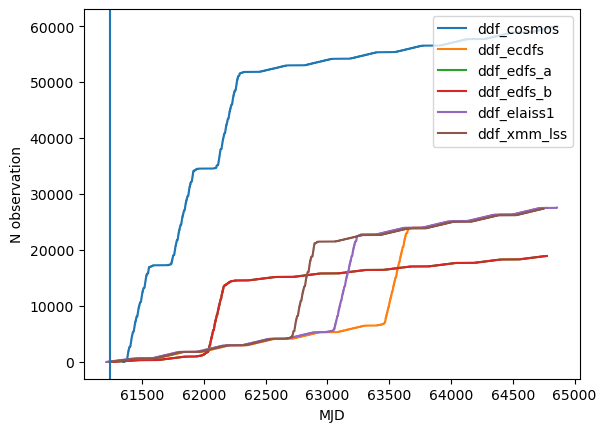

In [9]:
for target in targets:
    good = np.where(obs_array["target_name"] == target)[0]
    num = np.arange(good.size)
    mjd = obs_array["mjd"][good]
    plt.plot(np.sort(mjd), num, label=target)
plt.legend()
#plt.ylim([10,1e5])
plt.xlabel("MJD")
plt.ylabel("N observation")
plt.axvline(61242)